In [3]:
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn
import astropy.units as units
from astropy.table import Table, join

import sys
sys.path.insert(0, '.')
from mw_dynamics import query, selection, kinematics

plt.rcParams['figure.dpi'] = 110  # dpi - Dots Per Inch 

# 1. Data Acquisition

## 1.1. Downloading the APOGEE DR17 (SDSS) and Gaia DR3 Data

In [4]:
""" 1.1.a. APOGEE DR17 (SDSS) """  
apogee_dataset = query.fetch_apogee_dataset(dr=17, local_dir='data')

APOGEE DR17 data is already found: data\apogee_astroNN-DR17.fits


In [5]:
""" 1.1.b. GAIA DR3 """  
# Getting ID list from the apogee_dataset table:
gaia_ids_raw = apogee_dataset[selection.COLUMN_MAP["gaia_source_id"]]

# Filtering data from NaN, None or 0:
gaia_ids = [int(i) for i in gaia_ids_raw if i is not None and not numpy.isnan(i) and int(i)>0]

# Querying Gaia DR3 dataset:
gaia_dataset = query.fetch_gaia_dr3_dataset(source_ids=gaia_ids)

Gaia DR3 data is already found: data\gaia_dr3.fits


In [6]:
""" 1.1.c. Combining the APOGEE DR17 and Gaia DR3 data table taking as reference of 'source_id' """
dataset = join(apogee_dataset, gaia_dataset, keys='source_id', join_type='inner')
print(f'There are {len(dataset)} stars in the main combined data table')
dataset

There are 720982 stars in the main combined data table


APOGEE_ID,LOCATION_ID,TELESCOPE,RA_APOGEE,DEC_APOGEE,TEFF,TEFF_ERR,LOGG,LOGG_ERR,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H,FE_H_ERR,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA,DEC,pmra_1,pmra_error_1,ref_epoch,pmdec_1,pmdec_error_1,phot_g_mean_mag_1,bp_rp,g_rp,VHELIO_AVG,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,ra,dec,parallax,parallax_error,pmra_2,pmra_error_2,pmdec_2,pmdec_error_2,radial_velocity,radial_velocity_error,phot_g_mean_mag_2,ruwe
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,km / s,km / s,mag,
bytes18,int32,bytes8,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32
2M03003170+0008161,2093,apo25m,45.132108,0.137814,5780.8574,161.7498,4.100412,0.19276366,-0.3711875,0.038065936,-0.3396748,0.056596436,-0.34056208,0.14742574,-0.20170288,0.07242561,-0.50567,0.4274107,-0.311168,0.0516732,-0.25780863,0.09804092,-0.29315716,0.063271075,-0.24978566,1.3852366,-0.4487291,0.06891378,-0.33393428,0.15429959,-0.32064444,0.074549675,-0.5413349,0.19922921,-0.43484062,0.14278609,-0.44426933,0.141835,-0.50751007,0.15640938,-0.55461407,0.120849475,-0.43001375,0.07844468,-0.70012385,0.4763723,-0.41499853,0.07969294,409.68743896484375,60.474410175818186,30.524086452345742,2.440885066986084,0.36030170977639553,0.18186007116346195,368.71295166015625,54.42612136748066,370.4024994175685,2.5831414557971617,45.132144414036745,0.1378535532444834,4.722163881935847,0.023343084380030632,2016.0,18.657223456570794,0.016468381509184837,12.356247901916504,0.810368537902832,0.49047279357910156,38.26403,6.370143890380859,6.911157608032227,6.589427229446994,2.4611436670328084,2.007263228687403,2851858288640,8.369862900414725,0.001553919203146753,-0.2569848834364346,35.143005276070845,265.7657446547475,-2.4416450221504338,0.0017288495497930633,1.6828653429270997e-05,0.0019645723967377593,0.15433989245595542,0.1390781938636487,0.14437416696880762,0.9112410621565991,0.8453190410501303,0.8908809143057596,

## 1.2. Filtering Data and Detection the Red Giant Stars in the Milky Way Galaxy

In [7]:
""" 1.2.a. Filtering the APOGEE DR17 and Gaia DR3 Dataset according to the RUWE Parameter """
filtered_table = selection.quality_cuts(dataset, ruwe_max=1.4)

""" 1.2.b. Detection the Red Giant Stars in the Milky Way Galaxy """
red_giants = selection.select_red_giants(filtered_table, logg_max=3.5, teff_min=3500, teff_max=5500)
red_giants

APOGEE_ID,LOCATION_ID,TELESCOPE,RA_APOGEE,DEC_APOGEE,TEFF,TEFF_ERR,LOGG,LOGG_ERR,C_H,C_H_ERR,CI_H,CI_H_ERR,N_H,N_H_ERR,O_H,O_H_ERR,NA_H,NA_H_ERR,MG_H,MG_H_ERR,AL_H,AL_H_ERR,SI_H,SI_H_ERR,P_H,P_H_ERR,S_H,S_H_ERR,K_H,K_H_ERR,CA_H,CA_H_ERR,TI_H,TI_H_ERR,TIII_H,TIII_H_ERR,V_H,V_H_ERR,CR_H,CR_H_ERR,MN_H,MN_H_ERR,FE_H,FE_H_ERR,CO_H,CO_H_ERR,NI_H,NI_H_ERR,dist,dist_error,dist_model_error,nn_parallax,nn_parallax_error,nn_parallax_model_error,fakemag,fakemag_error,weighted_dist,weighted_dist_error,RA,DEC,pmra_1,pmra_error_1,ref_epoch,pmdec_1,pmdec_error_1,phot_g_mean_mag_1,bp_rp,g_rp,VHELIO_AVG,age,age_linear_correct,age_lowess_correct,age_total_error,age_model_error,source_id,galr,galphi,galz,galvr,galvt,galvz,galr_err,galphi_err,galz_err,galvr_err,galvt_err,galvz_err,galvr_galvt_corr,galvr_galvz_corr,galvt_galvz_corr,e,e_err,zmax,zmax_err,rperi,rperi_err,rap,rap_err,e_zmax_corr,e_rperi_corr,e_rap_corr,zmax_rperi_corr,zmax_rap_corr,rperi_rap_corr,jr,jr_err,Lz,Lz_err,jz,jz_err,jr_Lz_corr,jr_jz_corr,lz_jz_corr,omega_r,omega_r_err,omega_phi,omega_phi_err,omega_z,omega_z_err,theta_r,theta_r_err,theta_phi,theta_phi_err,theta_z,theta_z_err,rl,rl_err,Energy,Energy_err,EminusEc,EminusEc_err,ra,dec,parallax,parallax_error,pmra_2,pmra_error_2,pmdec_2,pmdec_error_2,radial_velocity,radial_velocity_error,phot_g_mean_mag_2,ruwe
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,km / s,km / s,mag,
bytes18,int32,bytes8,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float32,float32
2M03001491+0012569,2393,apo25m,45.062147,0.215807,4176.376,310.33902,3.0967062,1.1883569,-1.1520023,0.2706839,-1.5874728,0.45704818,-1.0173167,0.25787246,-1.168169,0.25140595,-1.4011111,0.30767816,-1.13935,0.1940535,-1.3104175,0.25384447,-1.2736005,0.22278646,-1.2012007,26.851732,-1.277542,0.2245854,-1.2167678,0.24599358,-1.08973,0.1325201,-1.3694273,0.20064956,-1.289572,0.4686055,-1.5701451,0.49017164,-1.0942428,0.18985091,-1.4572299,0.23123586,-1.3141046,0.48887002,-1.4140466,0.22314413,-1.222222,0.23205262,528.8662719726562,184.71987176139842,81.49005031121818,1.89083731174469,0.6604225760972802,0.29134856168776424,346.2435302734375,120.93427752872476,160.00242208298363,0.5133493762370127,45.06227669197522,0.21600441945474147,28.981163926528097,0.024188097566366196,2016.0,49.350705947102014,0.018283024430274963,14.068443298339844,1.6956253051757812,0.8822460174560547,6.8276553,8.191675186157227,8.96420669555664,8.61507854307814,2.822058977703657,1.7212811066024745,7284264691456,8.230746352220006,0.0007180192701103483,-0.09916947218095293,24.25840954431169,259.35583193841285,29.814672646111404,0.0003454255722206235,6.585839872858317e-06,0.0003878302453579951,0.10684223829790547,0.04589748451041872,0.09998166482407307,0.8718218077143477,0.6755434115106316,0.8103898394148191,0.22278136227634956,0.0003

# 2. Kinematic and Spatial Calculations

## 2.1. Coordinate Transformations and 3D Velocity Derivations of Red Giants

In [8]:
""" 2.1.a. Calculation of the Galactocentric 3D Velocities and Coordinates of the Red Giant Stars in Cartesian Coordinate System """
distance = (red_giants[selection.COLUMN_MAP["distance_pc"]]*units.pc).to(units.kpc)

cartesian_velocities = kinematics.observables_to_galactocentric(
    ra = red_giants['RA'] * units.deg,
    dec = red_giants['DEC'] * units.deg,
    distance = distance,
    pmra = red_giants['pmra_1'] * units.mas / units.yr,
    pmdec = red_giants['pmdec_1'] * units.mas / units.yr,
    radial_velocity = red_giants['radial_velocity']
)
cartesian_velocities

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in kpc
    [(-8.22770061, 0.0059108 , -0.09914827),
     (-8.22765924, 0.00590849, -0.09910135),
     (-8.58190367, 0.02612917, -0.49853473), ...,
     (-8.06517422, 0.06437639, -0.02548726),
     (-6.76685464, 1.54838437, -1.09376536),
     (-7.46796747, 0.7507435 , -0.52048514)]
 (v_x, v_y, v_z) in km / s
    [(-18.8915377 , 259.02422624,  34.16924151),
     (-18.87954496, 259.0189993 ,  34.15841305),
     ( 16.96287932, 243.65616806,   5.07175758), ...,
     (  4.56272076, 236.10762692,  15.85321946),
     ( 16.97320794, 186.08875682, -20.84184464),
     ( 19.43644719, 196.91198609,  -5.69378408)]>

In [9]:
""" 2.1.b. Calculation of the Galactocentric 3D Velocities and Coordinates of the Red Giant Stars in Cylindrical Coordinate System """
cylindrical_velocities = kinematics.galactocentric_cylindrical_velocities(cartesian_velocities)
cylindrical_velocities

{'R_kpc': array([8.22770273, 8.22766136, 8.58194345, ..., 8.06543114, 6.94174444,
        7.50560816], shape=(364608,)),
 'phi_rad': array([3.14087425, 3.14087453, 3.13854798, ..., 3.1336108 , 2.91664629,
        3.04140077], shape=(364608,)),
 'z_kpc': array([-0.09914827, -0.09910135, -0.49853473, ..., -0.02548726,
        -1.09376536, -0.52048514], shape=(364608,)),
 'v_R_kms': array([ 19.07761637,  19.06554802, -16.22094848, ...,  -2.67801942,
         24.96226892,   0.3570182 ], shape=(364608,)),
 'v_phi_kms': array([259.01058768, 259.00537465, 243.70668505, ..., 236.13652433,
        185.18639349, 197.86858842], shape=(364608,)),
 'v_z_kms': array([ 34.16924151,  34.15841305,   5.07175758, ...,  15.85321946,
        -20.84184464,  -5.69378408], shape=(364608,))}

In [10]:
""" 2.1.c. Merging the Cartesian and Cylindrical Values of the Red Giant Stars into a Table """
# 1. Merging the data of cartesian and cylindrical in a dictionary
data = {
    #Start ID
    'APOGEE_ID': red_giants['APOGEE_ID'],

    # 2.1.a. Cartesian Coordinates and Velocities (Galactocentric)
    'X_kpc': cartesian_velocities.x.to_value(units.kpc), 
    'Y_kpc': cartesian_velocities.y.to_value(units.kpc),
    'Z_kpc': cartesian_velocities.z.to_value(units.kpc),
    'Vx_kms': cartesian_velocities.v_x.to_value(units.km / units.s),
    'Vy_kms': cartesian_velocities.v_y.to_value(units.km / units.s),
    'Vz_kms': cartesian_velocities.v_z.to_value(units.km / units.s),

    # 2.1.b. Cylindrical Coordinates and Velocities (Galactocentric)
    'R_kpc': cylindrical_velocities["R_kpc"],
    'phi_rad': cylindrical_velocities["phi_rad"],
    'z_kpc': cylindrical_velocities["z_kpc"],
    'vR_kms': cylindrical_velocities[ "v_R_kms"],
    'Vphi_kms': cylindrical_velocities[ "v_phi_kms"],
    'vz_kms':cylindrical_velocities[ "v_z_kms"]
}

# 2. Generating a Pandas DataFrame
red_giant_kinematics = pandas.DataFrame(data)
red_giant_kinematics

,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms
0,b'2M03001491+0012569',-8.227701,0.005911,-0.099148,-18.891538,259.024226,34.169242,8.227703,3.140874,-0.099148,19.077616,259.010588,34.169242
1,b'2M03001491+0012569',-8.227659,0.005908,-0.099101,-18.879545,259.018999,34.158413,8.227661,3.140875,-0.099101,19.065548,259.005375,34.158413
2,b'2M03003264+0020060',-8.581904,0.026129,-0.498535,16.962879,243.656168,5.071758,8.581943,3.138548,-0.498535,-16.220948,243.706685,5.071758
3,b'2M03015585+0043303',-8.461544,0.019637,-0.355706,-73.714535,159.190409,-20.027169,8.461567,3.139272,-0.355706,74.083770,159.018911,-20.027169
4,b'2M03015585+0043303',-8.461732,0.019648,-0.355915,-73.734663,159.140813,-20.011602,8.461755,3.139271,-0.355915,74.103979,158.969177,-20.011602
...,...,...,...,...,...,...,...,...,...,...,...,...,...
364603,b'2M20595259-0028121',-5.222694,3.277297,-2.362233,25.998921,220.570681,-82.990832,6.165810,2.581190,-2.362233,95.217224,200.651563,-82.990832
364604,b'2M20595090-0019451',-6.938141,1.344464,-0.951612,10.124837,178.789227,16.470945,7.067205,2.950186,-0.951612,24.072895,177.450263,16.470945
364605,b'2M20591121-0017174',-8.065174,0.064376,-0.025487,4.562721,236.107627,15.853219,8.065431,3.133611,-0.025487,-2.678019,236.136524,15.853219
364606,b'2M20595928-0010220',-6.766855,1.548384,-1.093765,16.973208,186.088757,-20.841845,6.941744,2.916646,-1.093765,24.962269,185.186393,-20.841845


## 2.2. Selecting Red Giant Stars to Analyze

In [11]:
stars_to_analyze_mask = selection.select_outer_disk(
    red_giant_kinematics, 
    red_giant_kinematics["R_kpc"],
    red_giant_kinematics["z_kpc"],
    R_min=9.00,
    R_max=35.0,
    z_max=3.0
)
print(f"There are {stars_to_analyze_mask.sum()} stars to analyze")
red_giants_df = red_giant_kinematics[stars_to_analyze_mask]
red_giants_df

There are 117469 stars to analyze


,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms
23,b'2M03023140+0043323',-10.113540,0.109842,-2.178806,-40.745925,205.196114,-0.617401,10.114136,3.130732,-2.178806,42.972001,204.741502,-0.617401
24,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926
26,b'2M03024489+0053054',-10.212700,0.119412,-2.276378,54.459759,172.493823,-21.405477,10.213398,3.129901,-2.276378,-52.439292,173.118760,-21.405477
27,b'2M03024489+0053054',-10.151439,0.115913,-2.209068,53.423185,174.625565,-20.351250,10.152101,3.130175,-2.209068,-51.425892,175.224149,-20.351250
28,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414
...,...,...,...,...,...,...,...,...,...,...,...,...,...
352923,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339
352965,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN
352981,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739
352993,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382


## 2.3. Spatial Distribution of the Red Giant in the Milky Way

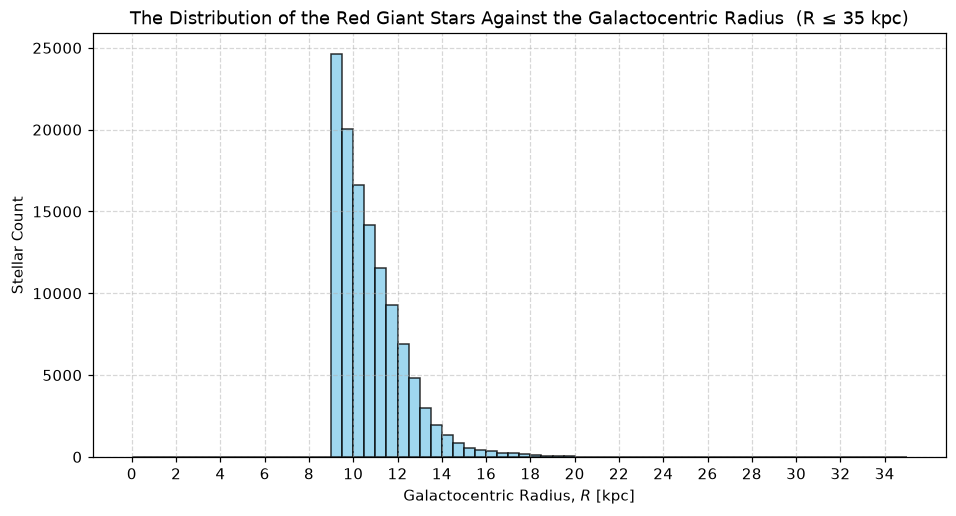

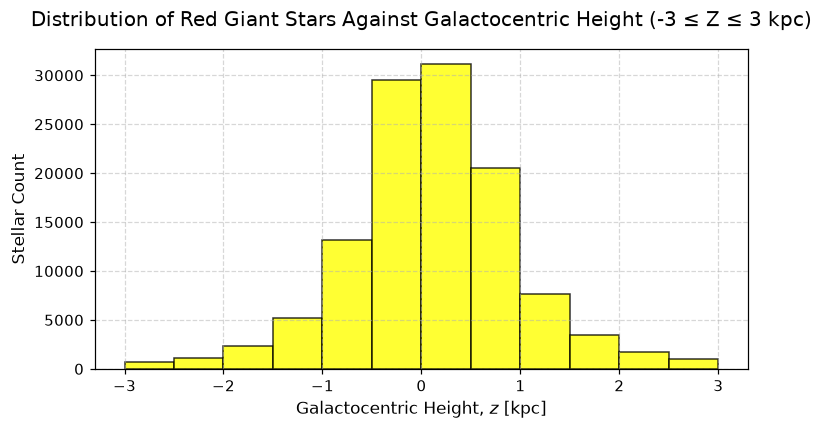

In [12]:
""" 2.3.a. The Distribution of the Red Giant Stars Against the Galactocentric Radius """

plt.figure(figsize=(10, 5))

# The range 0 to 35 are divided into 70 small boxes (each 0.5 kpc wide).
plt.hist(
    red_giants_df["R_kpc"],
    bins=70,
    range=(0, 35),
    color="skyblue",
    edgecolor="black",
    alpha=0.8,
)

# The X-axis values range from 0 to 35, plotted at intervals of 2.
plt.xticks(numpy.arange(0, 36, 2))

plt.title("The Distribution of the Red Giant Stars Against the Galactocentric Radius  (R ≤ 35 kpc)")
plt.xlabel("Galactocentric Radius, $R$ [kpc]")
plt.ylabel("Stellar Count")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


""" 2.3.b. The Distribution of the Red Giant Stars Against the Galactocentric Z Values """
plt.figure(figsize=(7, 4))

plt.hist(
    red_giants_df["z_kpc"],
    bins=12,
    range=(-3, 3), 
    color="yellow",
    edgecolor="black",
    alpha=0.8,
)

plt.title("Distribution of Red Giant Stars Against Galactocentric Height (-3 ≤ Z ≤ 3 kpc)", fontsize=13, pad=15)
plt.xlabel("Galactocentric Height, $z$ [kpc]", fontsize=11)
plt.ylabel("Stellar Count", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout() 

plt.show()

# 3. Galactic Dynamics and Kinematic Moment Calculations

## 3.1. Radial Binning and RGB Tracer Density
---
In this section, the RGB tracer sample is divided into 1-kpc-wide Galactocentric radial bins (R) between 9 and 35 kpc, and a minimum star count threshold (N ≥ 20) is applied to filter out bins with insufficient data to ensure statistical reliability. 

The number of stars decreases rapidly with increasing radius, from 44,670 stars in the 9–10 kpc bin to fewer than 20 stars beyond 22 kpc. For the initial Jeans analysis, only bins containing at least 20 stars are retained. This provides a preliminary usable radial range of approximately 9.5–21.5 kpc.

In [13]:
""" 3.1.a. Bin Edge and Center Calculation """

# Radial range used for the Jeans analysis
R_MIN = 9.00
R_MAX = 35.0
BIN_WIDTH = 1.00

# Construct radial bin edges
radial_bin_edges = numpy.arange(R_MIN, R_MAX+1, BIN_WIDTH)
print('Radial bin edges: ', radial_bin_edges)

# Calculate bin centres
radial_bin_centers = 0.5 * (radial_bin_edges[:-1] + radial_bin_edges[1:])
print("\nRadial bin centers: ", radial_bin_centers)

Radial bin edges:  [ 9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21. 22. 23. 24. 25. 26.
 27. 28. 29. 30. 31. 32. 33. 34. 35.]

Radial bin centers:  [ 9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5
 23.5 24.5 25.5 26.5 27.5 28.5 29.5 30.5 31.5 32.5 33.5 34.5]


In [14]:
""" 3.1.b. Applying Radial Bin Edges to Data """

# Binning red giant stars
assigned_radial_bins = red_giants_df.copy()
assigned_radial_bins["R_bin"] = pandas.cut(
    red_giants_df["R_kpc"],
    bins=radial_bin_edges,
    labels=radial_bin_centers,
    right=False,
    include_lowest=True
)
display(assigned_radial_bins)

# General analysis for binned red giants
radial_bin_counts = (
    assigned_radial_bins.groupby("R_bin", observed=False).size().reset_index(name="N_stars")
)
print(radial_bin_counts)

,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms,R_bin
23,b'2M03023140+0043323',-10.113540,0.109842,-2.178806,-40.745925,205.196114,-0.617401,10.114136,3.130732,-2.178806,42.972001,204.741502,-0.617401,10.5
24,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926,10.5
26,b'2M03024489+0053054',-10.212700,0.119412,-2.276378,54.459759,172.493823,-21.405477,10.213398,3.129901,-2.276378,-52.439292,173.118760,-21.405477,10.5
27,b'2M03024489+0053054',-10.151439,0.115913,-2.209068,53.423185,174.625565,-20.351250,10.152101,3.130175,-2.209068,-51.425892,175.224149,-20.351250,10.5
28,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414,10.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352923,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339,9.5
352965,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN,9.5
352981,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739,10.5
352993,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382,10.5


   R_bin  N_stars
0    9.5    44670
1   10.5    30814
2   11.5    20805
3   12.5    11719
4   13.5     4927
5   14.5     2171
6   15.5      944
7   16.5      631
8   17.5      393
9   18.5      187
10  19.5      111
11  20.5       38
12  21.5       24
13  22.5       10
14  23.5        2
15  24.5        7
16  25.5        6
17  26.5        2
18  27.5        2
19  28.5        1
20  29.5        1
21  30.5        1
22  31.5        0
23  32.5        1
24  33.5        1
25  34.5        1


In [15]:
""" 3.1.c. Selecting Usable Bin Groups """ 

# Selecting bins including more 20 stars
usable_radial_bins = radial_bin_counts[:13]
usable_radial_bins

,R_bin,N_stars
0,9.5,44670
1,10.5,30814
2,11.5,20805
3,12.5,11719
4,13.5,4927
5,14.5,2171
6,15.5,944
7,16.5,631
8,17.5,393
9,18.5,187


In [16]:
""" 3.1.d. Selecting Stars in Usable Radial Bins """

# Selecting stars being 9 ≤ R ≤ 22 kpc (from R_bin 9.5 to 21.5)
velocity_sample = assigned_radial_bins[assigned_radial_bins["R_bin"].isin(usable_radial_bins["R_bin"])].copy()
print(f"Number of stars used for velocity-moment analysis: {len(velocity_sample)}")
velocity_sample

Number of stars used for velocity-moment analysis: 117434


,APOGEE_ID,X_kpc,Y_kpc,Z_kpc,Vx_kms,Vy_kms,Vz_kms,R_kpc,phi_rad,z_kpc,vR_kms,Vphi_kms,vz_kms,R_bin
23,b'2M03023140+0043323',-10.113540,0.109842,-2.178806,-40.745925,205.196114,-0.617401,10.114136,3.130732,-2.178806,42.972001,204.741502,-0.617401,10.5
24,b'2M03023140+0043323',-10.136375,0.111101,-2.204027,-41.047964,204.715584,-0.367926,10.136984,3.130632,-2.204027,43.289182,204.253402,-0.367926,10.5
26,b'2M03024489+0053054',-10.212700,0.119412,-2.276378,54.459759,172.493823,-21.405477,10.213398,3.129901,-2.276378,-52.439292,173.118760,-21.405477,10.5
27,b'2M03024489+0053054',-10.151439,0.115913,-2.209068,53.423185,174.625565,-20.351250,10.152101,3.130175,-2.209068,-51.425892,175.224149,-20.351250,10.5
28,b'2M03024489+0053054',-10.124777,0.114390,-2.179772,52.972032,175.553373,-19.892414,10.125423,3.130295,-2.179772,-50.985369,176.140611,-19.892414,10.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352923,b'2M12101145-5000377',-4.078900,-8.217207,2.009886,-210.697748,50.387801,-6.003339,9.173872,-2.031548,2.009886,48.547442,211.129385,-6.003339,9.5
352965,b'2M12082932-4937451',-4.159071,-8.176903,2.049427,NaN,NaN,NaN,9.173855,-2.041329,2.049427,NaN,NaN,NaN,9.5
352981,b'2M12100585-4925257',-3.221469,-10.009229,2.559047,-183.869636,36.230303,-43.274739,10.514872,-1.882176,2.559047,21.844578,186.127624,-43.274739,10.5
352993,b'2M12055147-4944209',-3.421338,-9.878537,2.426772,41.454329,72.446553,-5.672382,10.454236,-1.904207,2.426772,-82.023712,-15.462055,-5.672382,10.5


In [17]:
""" 3.1.e. Grouping Stars by Galactocentric Radius """

radial_groups = velocity_sample.groupby("R_bin", observed=True)

## 3.2. First-Order Kinematic Moments: Mean Velocities and Velocity Dispersions
---
One of the foundational components of the Jeans equation, namely **mean velocity components** 
$$\langle V_R\rangle, \langle V_\phi\rangle, \langle V_z\rangle $$ 
and the corresponding **velocity dispersions**
$$\sigma_R, \sigma_\phi, \sigma_z$$
are calculated in the **Galactocentric cylindrical coordinate system for each radial bin.

In [18]:
""" 3.2.a. Mean Velocities and Velocity Dispersions """

# Population standard deviation
def population_std(values):
    return numpy.std(values, ddof=0)

# Calculation of the mean velocities and standard deviations 
velocity_moments = radial_groups.agg(
    # Number of stars
    N_stars = ("vR_kms", "size"),

    # Mean velocities
    mean_vR_kms = ("vR_kms", "mean"),
    mean_Vphi_kms = ("Vphi_kms", "mean"),
    mean_vz_kms = ("vz_kms", "mean"),

    # Velocity dispersions
    sigma_R_kms = ("vR_kms", population_std),
    sigma_phi_kms = ("Vphi_kms", population_std),
    sigma_z_kms = ("vz_kms", population_std)
).reset_index()

velocity_moments

,R_bin,N_stars,mean_vR_kms,mean_Vphi_kms,mean_vz_kms,sigma_R_kms,sigma_phi_kms,sigma_z_kms
0,9.5,44670,-4.637659,210.876669,1.150258,43.383880,38.533187,23.811943
1,10.5,30814,-2.258501,210.904363,1.932139,38.632456,34.280366,21.146143
2,11.5,20805,-0.183822,211.358536,3.044461,35.132205,32.649287,19.944103
3,12.5,11719,1.613775,210.702787,3.958466,32.152931,32.298579,18.817887
4,13.5,4927,-0.494640,205.644398,2.783831,33.055136,32.425972,21.057381
5,14.5,2171,-4.127828,201.594712,0.503252,33.868594,33.358187,21.705176
6,15.5,944,-10.387698,199.427907,-4.754648,34.559610,36.489755,24.048872
7,16.5,631,-11.796646,193.380216,-3.021583,37.158832,43.989234,24.625488
8,17.5,393,-15.389422,192.817514,-3.955171,29.932908,33.226849,27.764914
9,18.5,187,-13.986190,190.573596,-2.289674,22.774996,34.081092,20.918283


## 3.3. Second-Order Kinematic Moments
---
This subsection derives the total mean-square velocity components, namely $$\langle V_R^2\rangle, \langle V_\phi^2\rangle, \langle V_z^2\rangle$$ mathematically combining the previously computed mean velocities and velocity dispersions, which enter directly into the Jeans equation.


In [19]:
""" 3.3.a. Calculation of the Second Velocity Moments """

# Calculation of the Second Velocity Moments
velocity_moments["mean_vR2_kms2"] = (velocity_moments["mean_vR_kms"]**2 + velocity_moments["sigma_R_kms"]**2)
velocity_moments["mean_Vphi2_kms2"] = (velocity_moments["mean_Vphi_kms"]**2 + velocity_moments["sigma_phi_kms"]**2)
velocity_moments["mean_vz2_kms2"] = (velocity_moments["mean_vz_kms"]**2 + velocity_moments["sigma_z_kms"]**2)
velocity_moments

,R_bin,N_stars,mean_vR_kms,mean_Vphi_kms,mean_vz_kms,sigma_R_kms,sigma_phi_kms,sigma_z_kms,mean_vR2_kms2,mean_Vphi2_kms2,mean_vz2_kms2
0,9.5,44670,-4.637659,210.876669,1.150258,43.383880,38.533187,23.811943,1903.668954,45953.775852,568.331712
1,10.5,30814,-2.258501,210.904363,1.932139,38.632456,34.280366,21.146143,1497.567470,45655.793951,450.892531
2,11.5,20805,-0.183822,211.358536,3.044461,35.132205,32.649287,19.944103,1234.305641,45738.406823,407.035984
3,12.5,11719,1.613775,210.702787,3.958466,32.152931,32.298579,18.817887,1036.415224,45438.862577,369.782316
4,13.5,4927,-0.494640,205.644398,2.783831,33.055136,32.425972,21.057381,1092.886665,43341.062196,451.163009
5,14.5,2171,-4.127828,201.594712,0.503252,33.868594,33.358187,21.705176,1164.120638,41753.196727,471.367908
6,15.5,944,-10.387698,199.427907,-4.754648,34.559610,36.489755,24.048872,1302.270940,41102.992357,600.954925
7,16.5,631,-11.796646,193.380216,-3.021583,37.158832,43.989234,24.625488,1519.939613,39330.960750,615.544642
8,17.5,393,-15.389422,192.817514,-3.955171,29.932908,33.226849,27.764914,1132.813261,38282.617105,786.533826
9,18.5,187,-13.986190,190.573596,-2.289674,22.774996,34.081092,20.918283,714.313957,37479.816286,442.817160


## 3.4. Cross-Term Moments
---
The **cross term**,
$$ \langle V_R V_z \rangle $$
describe the relationship between the **radial** and **vertical** motions of stars.

If radial and vertical motions are independent, this term is small. A non-zero value indicates that these two velocity components are correlated.

In [20]:
""" 3.4.a. Calculation of Cross Term """

# Calculating the cross term (V_R * V_z) for each individual star
velocity_sample["cross_term_kms2"] = (velocity_sample["vR_kms"] * velocity_sample["vz_kms"])

# Calculating <V_R V_z> in each radial bin
cross_moments = (
    velocity_sample.groupby("R_bin", observed=True).agg(mean_cross_term_kms2=("cross_term_kms2", "mean")).reset_index()
)

# Adding the cross-term values to the velocitty-moments table
velocity_moments = velocity_moments.merge(cross_moments, on="R_bin", how="left")

# Printing the table
print(velocity_moments)

   R_bin  N_stars  mean_vR_kms  mean_Vphi_kms  mean_vz_kms  sigma_R_kms  \
0    9.5    44670    -4.637659     210.876669     1.150258    43.383880   
1   10.5    30814    -2.258501     210.904363     1.932139    38.632456   
2   11.5    20805    -0.183822     211.358536     3.044461    35.132205   
3   12.5    11719     1.613775     210.702787     3.958466    32.152931   
4   13.5     4927    -0.494640     205.644398     2.783831    33.055136   
5   14.5     2171    -4.127828     201.594712     0.503252    33.868594   
6   15.5      944   -10.387698     199.427907    -4.754648    34.559610   
7   16.5      631   -11.796646     193.380216    -3.021583    37.158832   
8   17.5      393   -15.389422     192.817514    -3.955171    29.932908   
9   18.5      187   -13.986190     190.573596    -2.289674    22.774996   
10  19.5      111    -0.772701     165.459039    -8.361517    47.898534   
11  20.5       38     5.500845     105.144235     2.703647    87.828301   
12  21.5       24   -24.6

## 3.5. Radial Gradient of the Radial Velocity Moment
---
A critical numerical input for solving the Jeans equation in Chapter 4, this subsection covers the computation of the radial gradient of the mean-square radial velocity component using numerical differentiation methods.
$$\frac{\partial \langle V_R^2 \rangle}{\partial R}$$


In [21]:
""" 3.5.a. Radial Gradient of the Radial Velocity Second Moment """

# Keep only radial bins with a sufficient number of stars
gradient_sample = velocity_moments.loc[velocity_moments["N_stars"] > 20, ["R_bin", "N_stars", "mean_vR2_kms2"]
].copy()

print(gradient_sample)

# Gradient calculation
R = gradient_sample["R_bin"].to_numpy()
vR2 = gradient_sample["mean_vR2_kms2"].to_numpy()
dvR2_dR = numpy.gradient(vR2, R)

# Adding the results to the table
gradient_sample["d_mean_vR2_dR"] = dvR2_dR
print("\n", gradient_sample)

   R_bin  N_stars  mean_vR2_kms2
0    9.5    44670    1903.668954
1   10.5    30814    1497.567470
2   11.5    20805    1234.305641
3   12.5    11719    1036.415224
4   13.5     4927    1092.886665
5   14.5     2171    1164.120638
6   15.5      944    1302.270940
7   16.5      631    1519.939613
8   17.5      393    1132.813261
9   18.5      187     714.313957
10  19.5      111    2294.866638
11  20.5       38    7744.069809
12  21.5       24    2762.731465

    R_bin  N_stars  mean_vR2_kms2  d_mean_vR2_dR
0    9.5    44670    1903.668954    -406.101484
1   10.5    30814    1497.567470    -334.681656
2   11.5    20805    1234.305641    -230.576123
3   12.5    11719    1036.415224     -70.709488
4   13.5     4927    1092.886665      63.852707
5   14.5     2171    1164.120638     104.692138
6   15.5      944    1302.270940     177.909488
7   16.5      631    1519.939613     -84.728840
8   17.5      393    1132.813261    -402.812828
9   18.5      187     714.313957     581.026688
10  19.5

## 3.6. Vertical Gradient of the Cross Term
---
In this section, the **vertical gradient of the cross term**,
$$\frac{\partial \langle V_R V_z \rangle}{\partial z}$$
is calculated to account for the final term in the Jeans equation (See Chapter 4). The vertical height is restricted to **-3 < z < 3 kpc** and divided into **1 kpc bins**.

The numerical gradient is calculated using the mean cross-term $ \langle V_R V_z \rangle $ values previously derived in Section 3.4. Cross-Term Moments. **6 different gradient cross-term values** are obtained as a result of the calculation. 

To accurately capture the dynamics close to the Galactic disk, only the gradient results within the mid-plane region—specifically between **-0.5 and 0.5 kpc**—are extracted and utilized in the subsequent Jeans equation calculations.

In [22]:
""" 3.6.a. Binning Process of the z Values """

# Filtering the z values (-3 < z < 3)
cross_term_sample = velocity_sample[velocity_sample["z_kpc"].abs() < 3.0].copy()

# The edges of the bins
z_bin_width = 1.00 #kpc
z_edges = numpy.arange(-3.00, 3.00+z_bin_width, z_bin_width)
print(z_edges)

# Assigning stars to z bins
cross_term_sample["z_bin"] = pandas.cut(cross_term_sample["z_kpc"], bins=z_edges, include_lowest=True)

# Calculating the centre of each z bin
cross_term_sample["z_bin_center"] = cross_term_sample["z_bin"].apply(lambda interval: interval.mid)

cross_term_sample[["R_bin", "z_kpc", "z_bin_center"]]

[-3. -2. -1.  0.  1.  2.  3.]


,R_bin,z_kpc,z_bin_center
23,10.5,-2.178806,-2.5005
24,10.5,-2.204027,-2.5005
26,10.5,-2.276378,-2.5005
27,10.5,-2.209068,-2.5005
28,10.5,-2.179772,-2.5005
...,...,...,...
352923,9.5,2.009886,2.5000
352965,9.5,2.049427,2.5000
352981,10.5,2.559047,2.5000
352993,10.5,2.426772,2.5000


In [23]:
""" 3.6.b. Classifying Cross-Term Moments in R-z plane """

# Classifying the RGB based on the values of R and z
cross_term_Rz = cross_term_sample.groupby(["R_bin","z_bin","z_bin_center"], observed=True).agg(
    N_stars=("cross_term_kms2", "count"),
    mean_cross_term_kms2=("cross_term_kms2", "mean")
).reset_index()

print(cross_term_Rz)

   R_bin           z_bin z_bin_center  N_stars  mean_cross_term_kms2
0    9.5  (-3.001, -2.0]      -2.5005      528          -1339.477325
1    9.5    (-2.0, -1.0]      -1.5000     1602           -308.001854
2    9.5     (-1.0, 0.0]      -0.5000    14649            -45.032282
3    9.5      (0.0, 1.0]       0.5000    19149             85.200060
4    9.5      (1.0, 2.0]       1.5000     3550            343.685780
..   ...             ...          ...      ...                   ...
73  21.5    (-2.0, -1.0]      -1.5000        2           -118.970288
74  21.5     (-1.0, 0.0]      -0.5000        0                   NaN
75  21.5      (0.0, 1.0]       0.5000        0                   NaN
76  21.5      (1.0, 2.0]       1.5000        1           -299.640586
77  21.5      (2.0, 3.0]       2.5000        0                   NaN

[78 rows x 5 columns]


In [24]:
""" 3.6.c. Vertical Gradient of the Cross Term """

vertical_gradient_results = []

for R_bin, group in cross_term_Rz.groupby("R_bin", observed=True):

    # Sort according to vertical position
    group = group.sort_values("z_bin_center")

    z = group["z_bin_center"].to_numpy(dtype=float)

    cross_term = group["mean_cross_term_kms2"].to_numpy(dtype=float)

    # At least three z points are required
    if len(z) < 3:
        continue

    # Numerical derivative (d<V_R V_z>/dz):
    d_cross_dz = numpy.gradient(cross_term, z)

    vertical_gradient_results.append(
            pandas.DataFrame({
            "R_bin": float(R_bin),
            "z_bin_center": z,
            "mean_cross_term_kms2": cross_term,
            "vertical_gradient_crossTerm": d_cross_dz
        })
    )

vertical_gradient = pandas.concat(vertical_gradient_results, ignore_index=True)

print(vertical_gradient)

    R_bin  z_bin_center  mean_cross_term_kms2  vertical_gradient_crossTerm
0     9.5       -2.5005          -1339.477325                  1030.959991
1     9.5       -1.5000           -308.001854                   646.868807
2     9.5       -0.5000            -45.032282                   196.600957
3     9.5        0.5000             85.200060                   194.359031
4     9.5        1.5000            343.685780                   540.593528
..    ...           ...                   ...                          ...
73   21.5       -1.5000           -118.970288                          NaN
74   21.5       -0.5000                   NaN                          NaN
75   21.5        0.5000                   NaN                          NaN
76   21.5        1.5000           -299.640586                          NaN
77   21.5        2.5000                   NaN                          NaN

[78 rows x 4 columns]


In [25]:
""" 3.6.d. Cross-Term Contribution to the Jeans Equation """

# Selecting the vertical gradient values closest to the Galactic mid-plane.
# The z bins closest to z = 0 are centered at -0.5 and +0.5 kpc.
midplane_gradient = vertical_gradient[vertical_gradient["z_bin_center"].isin([-0.5, 0.5])].copy()

# Selecting the values of R = 9.5 ... 21.5 kpc
midplane_gradient = midplane_gradient[midplane_gradient["R_bin"].between(9.5, 21.5)].copy()

# Calculating the mean vertical gradient of the cross term from the two bins closest to the Galactic mid-plane.
cross_gradient = (midplane_gradient.groupby("R_bin", observed=True).agg(vertical_gradient_crossTerm=(
            "vertical_gradient_crossTerm",
            "mean")
).reset_index())

cross_gradient

,R_bin,vertical_gradient_crossTerm
0,9.5,195.479994
1,10.5,121.386995
2,11.5,75.310765
3,12.5,60.464840
4,13.5,50.736795
5,14.5,45.195795
6,15.5,12.617638
7,16.5,-233.607484
8,17.5,10.048532
9,18.5,-218.766630


## 3.7. Jeans Equation Terms Table

In [26]:
table_one = pandas.merge(
    velocity_moments[["R_bin", "mean_vR2_kms2", "mean_Vphi2_kms2", "mean_vz2_kms2"]],
    gradient_sample[["R_bin", "d_mean_vR2_dR"]],
    on="R_bin",
    how="inner"
)

jeans_terms_table = pandas.merge(
    table_one,
    cross_gradient[["R_bin", "vertical_gradient_crossTerm"]],
    on="R_bin",
    how="inner"
)
jeans_terms_table


,R_bin,mean_vR2_kms2,mean_Vphi2_kms2,mean_vz2_kms2,d_mean_vR2_dR,vertical_gradient_crossTerm
0,9.5,1903.668954,45953.775852,568.331712,-406.101484,195.479994
1,10.5,1497.567470,45655.793951,450.892531,-334.681656,121.386995
2,11.5,1234.305641,45738.406823,407.035984,-230.576123,75.310765
3,12.5,1036.415224,45438.862577,369.782316,-70.709488,60.464840
4,13.5,1092.886665,43341.062196,451.163009,63.852707,50.736795
5,14.5,1164.120638,41753.196727,471.367908,104.692138,45.195795
6,15.5,1302.270940,41102.992357,600.954925,177.909488,12.617638
7,16.5,1519.939613,39330.960750,615.544642,-84.728840,-233.607484
8,17.5,1132.813261,38282.617105,786.533826,-402.812828,10.048532
9,18.5,714.313957,37479.816286,442.817160,581.026688,-218.766630


# 4. Circular Velocity from the Jeans Equation

In [31]:
# Radial scale length adopted from Jiao et al. (2023)
h_R = 2.5 # kpc

# Converting the R_bin expressions to numerical float values
R = jeans_terms_table["R_bin"].astype(float)

# 1st term of equation
term_1 = jeans_terms_table["mean_Vphi2_kms2"]

# 2nd term of equation
term_2 = ((R - h_R)/h_R) * jeans_terms_table["mean_vR2_kms2"]

# 3rd term of equation
term_3 = -R * jeans_terms_table["d_mean_vR2_dR"]

# 4th term of Jeans equation
term_4 = -R * jeans_terms_table["vertical_gradient_crossTerm"]

# Calculating circular velocity from Jeans equation (cross-term temporarily neglected)
V_circ_squared_kms2 = term_1 + term_2 + term_3 + term_4
V_circ_kms = numpy.sqrt(numpy.maximum(V_circ_squared_kms2, 0))

# Generating a table
jeans_term_value = {
    "R_bin":jeans_terms_table["R_bin"],
    "N_stars":gradient_sample["N_stars"],
    "1st term":term_1,
    "2nd term":term_2,
    "3rd term":term_3,
    "4th term":term_4,
    "V_circ_squared_kms2":V_circ_squared_kms2,
    "V_circ_kms":V_circ_kms
}
jeans_terms_value_table = pandas.DataFrame(jeans_term_value)
jeans_terms_value_table

,R_bin,N_stars,1st term,2nd term,3rd term,4th term,V_circ_squared_kms2,V_circ_kms
0,9.5,44670,45953.775852,5330.273070,3857.964095,-1857.059941,53284.953076,230.835338
1,10.5,30814,45655.793951,4792.215904,3514.157392,-1274.563447,52687.603800,229.537805
2,11.5,20805,45738.406823,4443.500307,2651.625416,-866.073802,51967.458744,227.963722
3,12.5,11719,45438.862577,4145.660895,883.868601,-755.810499,49712.581574,222.963184
4,13.5,4927,43341.062196,4808.701324,-862.011545,-684.946735,46602.805240,215.876829
5,14.5,2171,41753.196727,5587.779061,-1518.035998,-655.339033,45167.600757,212.526706
6,15.5,944,41102.992357,6771.808889,-2757.597060,-195.573391,44921.630794,211.947236
7,16.5,631,39330.960750,8511.661834,1398.025853,3854.523493,53095.171930,230.423896
8,17.5,393,38282.617105,6796.879566,7049.224489,-175.849315,51952.871844,227.931726
9,18.5,187,37479.816286,4571.609327,-10748.993734,4047.182658,35349.614536,188.014932
